In [1]:
from trade.datamanager.market_data import MarketTimeseries
from trade.datamanager.utils.cache import _data_structure_cache_check_missing
from trade.optionlib.assets.dividend import get_div_histories, infer_frequency, FREQ_MAP, get_div_schedule
from trade.helpers.decorators import cProfiler
from trade.helpers.helper import print_top_cprofile_stats

/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


2026-02-13 09:42:18 trade.helpers.Logging INFO: Logging Root Directory: /Users/chiemelienwanisobi/cloned_repos/QuantTools/logs
2026-02-13 09:42:18 [test] trade.helpers.clear_cache INFO: No expired caches to delete on 2026-02-13.
2026-02-13 09:42:21 [test] dbase.DataAPI.ThetaData.proxy INFO: Refreshed proxy URL: http://54.205.248.219:5500/thetadata
2026-02-13 09:42:21 [test] dbase.DataAPI.ThetaData.proxy INFO: Using Proxy URL: http://54.205.248.219:5500/thetadata
2026-02-13 09:42:21 [test] dbase.DataAPI.ThetaData INFO: Using V2 of the ThetaData API
Fetching rates data from yfinance directly during market hours
YF.download() has changed argument auto_adjust default to True


In [2]:
ts = MarketTimeseries()
ts.clear_caches()

Fetching rates data from yfinance directly during market hours
2026-02-13 09:42:48 [test] trade.datamanager.market_data INFO: All MarketTimeseries caches have been cleared.


In [4]:
func = cProfiler(ts.get_timeseries)

res, stat = func("BAX", start_date="2014-01-01")

2026-02-13 09:42:58 [test] trade.datamanager.utils INFO: Max date 2026-02-12 for key: BAX is not today. Skipping today's data check.
2026-02-13 09:42:58 [test] trade.datamanager.utils INFO: Caching timeseries data structure for key: BAX with date range 2014-01-02 to 2026-02-12, missing dates within range: []
2026-02-13 09:42:58 [test] trade.datamanager.market_data INFO: Loaded spot data for symbol BAX into cache.
2026-02-13 09:42:58 [test] trade.datamanager.utils INFO: Converting old cache data structure to new for key: BAX
2026-02-13 09:42:58 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: BAX.
2026-02-13 09:42:58 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: BAX
2026-02-13 09:42:58 [test] trade.datamanager.utils INFO: Sanitizing data from 2014-01-02 00:00:00 to 2026-02-12 00:00:00...
2026-02-13 09:42:59 [test] trade.datamanager.utils INFO: Max date 2026-02-12 for key: BAX is not today. Skipping today's data c

In [6]:
ts.get_at_index("BAX", index = "2014-01-02")

2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: BAX.
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: BAX
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: Sanitizing data from 2014-01-02 00:00:00 to 2014-01-02 00:00:00...
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: BAX.
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: BAX
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: Sanitizing data from 2014-01-02 00:00:00 to 2014-01-02 00:00:00...
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: No missing dates within cached data range for key: BAX.
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: BAX
2026-02-13 09:47:25 [test] trade.datamanager.utils INFO: Sanitizing data from 2014-01-02 00:00:

AtIndexResult(sym=BAX, date=2014-01-02)

In [58]:
print_top_cprofile_stats(stat)

Function                                                                                                                         CumTime   RatioToTop
------------------------------------------------------------------------------------------------------------------------------------------------------
_get_spot_timeseries                                                                                                              0.0249         1.00
_data_structure_cache_check_missing                                                                                               0.0236         0.95
change_to_last_busday                                                                                                             0.0120         0.48
_comprehensive_cache_check                                                                                                        0.0116         0.47
to_datetime                                                                                        

In [3]:
ts._load_split_factor_into_cache("C", start="2020-01-01")

2026-02-02 20:26:10 [test] trade.datamanager.utils INFO: Cutting off today's data for key: C to avoid saving partial day data.
2026-02-02 20:26:10 [test] trade.datamanager.market_data INFO: Loaded chain spot data for symbol C into cache.
2026-02-02 20:26:10 [test] trade.datamanager.market_data INFO: Loaded split factor data for symbol C into cache.


In [4]:
ts._spot["C"]

[autoreload of trade.datamanager.rates failed: Traceback (most recent call last):
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_re

,open,high,low,close,volume,chain_price,unadjusted_close,split_ratio,cum_split,split_factor,max_cum_split,is_split_date
Date,,,,,,,,,,,,
2005-01-03,303.826962,303.826962,298.866522,299.300568,1474660,299.300568,299.300568,1.0,1.0,1.0,1.0,False
2005-01-04,299.362613,302.400898,295.766300,296.758392,1584770,296.758392,296.758392,1.0,1.0,1.0,1.0,False
2005-01-05,297.936409,302.462802,297.750400,300.478638,1893350,300.478638,300.478638,1.0,1.0,1.0,1.0,False
2005-01-06,302.586728,305.314965,302.214691,303.392792,1804990,303.392792,303.392792,1.0,1.0,1.0,1.0,False
2005-01-07,304.446955,304.508964,301.346680,301.656708,1280370,301.656708,301.656708,1.0,1.0,1.0,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-26,113.900002,115.480003,113.860001,114.820000,11728700,114.820000,114.820000,1.0,1.0,1.0,1.0,False
2026-01-27,114.900002,115.970001,113.699997,114.790001,11976800,114.790001,114.790001,1.0,1.0,1.0,1.0,False
2026-01-28,114.599998,115.709999,113.139999,114.199997,11378300,114.199997,114.199997,1.0,1.0,1.0,1.0,False


In [5]:
ts._get_chain_spot_timeseries("C", start="2005-01-01", end="2024-06-20")

2026-02-02 20:26:11 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:11 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2024-06-20...


,open,high,low,close,volume,chain_price,unadjusted_close,split_ratio,cum_split,split_factor,max_cum_split,is_split_date
datetime,,,,,,,,,,,,
2005-01-03,303.827024,303.827024,298.866582,299.300629,1474660,299.300629,299.300629,1.0,1.0,1.0,1.0,False
2005-01-04,299.362520,302.400805,295.766209,296.758301,1584770,296.758301,296.758301,1.0,1.0,1.0,1.0,False
2005-01-05,297.936378,302.462771,297.750369,300.478607,1893350,300.478607,300.478607,1.0,1.0,1.0,1.0,False
2005-01-06,302.586880,305.315119,302.214843,303.392944,1804990,303.392944,303.392944,1.0,1.0,1.0,1.0,False
2005-01-07,304.447047,304.509056,301.346772,301.656799,1280370,301.656799,301.656799,1.0,1.0,1.0,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-13,57.076864,57.669125,56.503709,57.535389,9358200,57.535389,57.535389,1.0,1.0,1.0,1.0,False
2024-06-14,56.780739,57.153294,56.035636,56.675663,10511000,56.675663,56.675663,1.0,1.0,1.0,1.0,False
2024-06-17,56.570581,57.821971,56.217132,57.373001,15527500,57.373001,57.373001,1.0,1.0,1.0,1.0,False


In [6]:
t = ts.get_timeseries("C", start_date="2005-01-01", end_date="2024-06-20")

2026-02-02 20:26:11 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:11 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2024-06-20...
2026-02-02 20:26:12 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:12 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2024-06-20...
2026-02-02 20:26:12 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:12 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2026-01-30...


In [7]:
ts._get_split_factor_timeseries("C", start="2005-01-01", end="2024-06-20")

2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2026-01-30...


datetime
2005-01-03    1.0
2005-01-04    1.0
2005-01-05    1.0
2005-01-06    1.0
2005-01-07    1.0
             ... 
2026-01-26    1.0
2026-01-27    1.0
2026-01-28    1.0
2026-01-29    1.0
2026-01-30    1.0
Name: split_factor, Length: 5303, dtype: float64

In [8]:
ts.get_at_index("C", index="2024-06-20")

2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Sanitizing data from 2024-06-20 00:00:00 to 2024-06-20 00:00:00...
2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Sanitizing data from 2024-06-20 00:00:00 to 2024-06-20 00:00:00...
2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:13 [test] trade.datamanager.utils INFO: Sanitizing data from 2024-06-20 00:00:00 to 2026-01-30...


[autoreload of trade.datamanager.rates failed: Traceback (most recent call last):
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_re

AtIndexResult(sym=C, date=2024-06-20)

In [64]:
ts.get_at_index("C", index="2024-06-20", ).dividend_yield

2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Sanitizing data from 2024-06-20 00:00:00 to 2024-06-20 00:00:00...
2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Sanitizing data from 2024-06-20 00:00:00 to 2024-06-20 00:00:00...
2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Sanitizing data from 2024-06-20 00:00:00 to 2024-06-20 00:00:00...
2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 22:21:49 [test] trade.datamanager.utils INFO: Sanitizing data from 2024-06-20 00:00:00 to 2026-01-30...


np.float64(0.009152458208936249)

[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

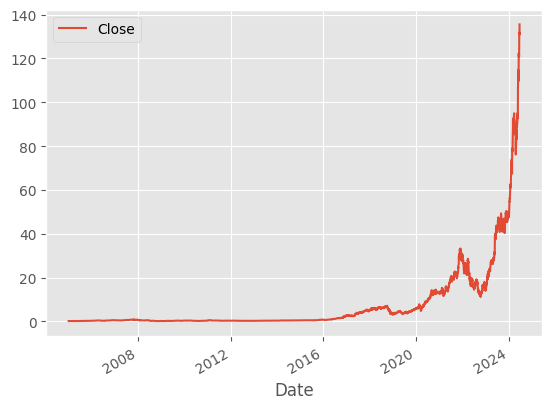

In [10]:
import yfinance as yf
data = yf.download("NVDA", start="2005-01-01", end="2024-06-20", back_adjust=True, auto_adjust=True, multi_level_index=False)
data.plot(y="Close")

In [11]:
ts.get_timeseries("C", start_date="2005-01-01", end_date="2024-06-20")

2026-02-02 20:26:15 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:15 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2024-06-20...
2026-02-02 20:26:15 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:15 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2024-06-20...
2026-02-02 20:26:16 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:16 [test] trade.datamanager.utils INFO: Sanitizing data from 2005-01-01 to 2026-01-30...


TimeseriesData(spot=True, chain_spot=True, dividends=True, additional_data_keys=[])

In [12]:
_data_structure_cache_check_missing(
    cached_data=ts._split_factor.get("C"),
    start_dt="2020-01-01",
    end_dt="2024-06-20",
    key="C",
)

2026-02-02 20:26:16 [test] trade.datamanager.utils INFO: Cache hit for timeseries data structure key: C
2026-02-02 20:26:16 [test] trade.datamanager.utils INFO: Sanitizing data from 2020-01-01 to 2024-06-20...


[autoreload of trade.datamanager.rates failed: Traceback (most recent call last):
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/chiemelienwanisobi/miniconda3/envs/openbb_new_use/lib/python3.11/importlib/__init__.py", line 169, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 621, in _exec
  File "<frozen importlib._bootstrap_external>", line 936, in exec_module
  File "<frozen importlib._bootstrap_external>", line 1074, in get_code
  File "<frozen importlib._bootstrap_external>", line 1004, in source_to_code
  File "<frozen importlib._bootstrap>", line 241, in _call_with_frames_re

(datetime
 2020-01-02    1.0
 2020-01-03    1.0
 2020-01-06    1.0
 2020-01-07    1.0
 2020-01-08    1.0
              ... 
 2024-06-13    1.0
 2024-06-14    1.0
 2024-06-17    1.0
 2024-06-18    1.0
 2024-06-20    1.0
 Name: split_factor, Length: 1124, dtype: float64,
 False,
 '2020-01-01',
 '2024-06-20')

In [15]:
import pandas as pd
from datetime import datetime, timedelta
t = get_div_schedule("AAPL")
def resample_dividends_to_daily(div_series: pd.Series, buffer: int = 30) -> pd.Series:
    """Resample dividend series to daily frequency with forward fill."""

    freq = infer_frequency(div_series)
    if freq is None:
        raise ValueError("Could not infer frequency.")
    freq_days = FREQ_MAP[freq] * 30 # Approximate to days
    freq_days += buffer

    ## First, resample to 1b (daily business days)
    resampled = div_series.resample("1b").ffill()

    ## Next, the resampled is clearly missing last dividends to today or end_date,
    ## SO we will forward fill the last known dividend to today. But with some rules.
    ## There are cases where dividends were discontinued, so we will only forward fill if the last known dividend date - today is less than freq_days
    ## If not we fill with zeros
    last_div_date = div_series.dropna().index[-1]
    today = datetime.now()
    days_since_last_div = (today - last_div_date).days

    ## Add additional days to ffill into
    resampled = resampled.reindex(pd.date_range(start=resampled.index[0], end=today, freq="1b"))
    if days_since_last_div <= freq_days:
        resampled = resampled.ffill()
    else:
        print("Filling with zeros as dividends seem to be discontinued.")
        resampled.loc[last_div_date + timedelta(days=1): today] = 0.0
    return resampled

In [ ]:

from openbb import obb
import pandas as pd
from trade.optionlib.config.defaults import (
    OPTION_TIMESERIES_START_DATE,
)
from trade.helpers.Logging import setup_logger
from trade.helpers.helper import CustomCache
from dataclasses import dataclass
from trade.datamanager.vars import DM_GEN_PATH

logger = setup_logger("trade.optionlib.utils.market_data")


@dataclass
class SavedDividendsResult:
    symbol: str
    historicals: pd.Series
    resampled_timeseries: pd.Series
    last_updated: datetime

## Cache has to be in memory. Incase dividends update on another date
DIVIDEND_CACHE = CustomCache(
    location=DM_GEN_PATH,
    fname="discrete_dividends_timeseries",
    clear_on_exit=False,
    expire_days=365
)


def get_div_schedule(ticker, 
                     filter_specials=True):
    """
    Fetch the dividend schedule for a given ticker.
    If the ticker is not in the cache, it fetches the data from yfinance and caches it.
    If the ticker is in the cache, it retrieves the data from the cache.
    If filter_specials is True, it filters out dividends >= 7.5.
    Returns a DataFrame with the dividend schedule.
    """

    ## We're going to use a multi-level dividend retrieval. CustomCache is on disk cache
    ## 1. We first check if the symbol is in the on disk DIVIDEND_CACHE
    ## 2. If not, we fetch from yfinance via openbb and store in DIVIDEND_CACHE and save with last_updated
    ## 3. If in cache, we retrieve from cache, but still check last_updated. 
    ##    We will use a weekly update policy to refresh dividends
    ## 4. Return the dividend schedule DataFrame

    # Check if ticker is in cache
    key = (ticker, filter_specials)
    if key not in DIVIDEND_CACHE:
        try:
            div_history = obb.equity.fundamental.dividends(symbol=ticker, provider="yfinance").to_df()
            div_history.set_index("ex_dividend_date", inplace=True)
            div_history["amount"] = div_history["amount"].astype(float)
            div_history.index = pd.to_datetime(div_history.index)
            dividends_data = SavedDividendsResult(
                symbol=ticker,
                historicals=div_history["amount"],
                resampled_timeseries=None,
                last_updated=datetime.now(),
            )
        except Exception as e:  # noqa
            div_history = pd.DataFrame(
                {"amount": [0]}, index=pd.bdate_range(start=OPTION_TIMESERIES_START_DATE, end=datetime.now(), freq="1Q")
            )
            dividends_data = SavedDividendsResult(
                symbol=ticker,
                historicals=div_history["amount"],
                resampled_timeseries=None,
                last_updated=datetime.now(),
            )
        DIVIDEND_CACHE[key] = dividends_data

    else:
        print(f"Ticker {ticker} found in dividend cache.")
        dividends_data: SavedDividendsResult = DIVIDEND_CACHE[key]
        # Check if we need to refresh (if last_updated > 7 days)
        if (datetime.now() - dividends_data.last_updated).days > 7:
            del DIVIDEND_CACHE[key]
            return get_div_schedule(ticker, filter_specials=filter_specials)

    # Filter out dividends >= 7.5
    if filter_specials:
        dividends_data.historicals = dividends_data.historicals[dividends_data.historicals < 7.5]

    return dividends_data.historicals.sort_index()

In [ ]:
def get_daily_dividends_timeseries(ticker, start, end):
    """Get daily resampled dividend timeseries for a given ticker between start and end dates."""
            
    # Else we fallthrough to refetching the schedule
    div_series = get_div_schedule(ticker)
    daily_div_series = resample_dividends_to_daily(div_series)
    daily_div_series = daily_div_series[start:end]
    return daily_div_series

daily = get_daily_dividends_timeseries("T",'2023-01-02','2023-12-31')
daily

Ticker T found in dividend cache.


2023-01-02    0.278
2023-01-03    0.278
2023-01-04    0.278
2023-01-05    0.278
2023-01-06    0.278
              ...  
2023-12-25    0.278
2023-12-26    0.278
2023-12-27    0.278
2023-12-28    0.278
2023-12-29    0.278
Freq: B, Name: amount, Length: 260, dtype: float64